# **04. CLTV Using Probabilistic Models**

## **Introduction**

We aim to compute __Customer Lifetime Value (CLTV)__ using a __probabilistic modeling approach__. Specifically, we will apply the __BG/NBD__ and __Pareto/NBD__ models to estimate customer purchasing behavior over time. In addition, the __Gamma-Gamma model__  will be used to evaluate the expected monetary value of transactions. Together, these models allow us to estimate the average profit that can be generated from each customer, providing a robust framework for understanding long-term customer profitability.

### **Goal**

- **Estimate CLTV**: Quantify the long-term value each customer contributes to the business.

- **Model purchase frequency**: Use BG/NBD and Pareto/NBD models to capture how often customers are likely to buy and how long they remain active.

- **Assess transaction value**: Apply the Gamma-Gamma model to estimate the average profit we can earn for each customer.



### **1. Requirements**

In [86]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sidetable
from pathlib import Path
from IPython.display import display
from IPython.display import Markdown


In [87]:
# display setting
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

import warnings
warnings.simplefilter("ignore", category=FutureWarning)

# Display markdown formatted output like bold, italic bold etc.'''
def display_md(string):
    display(Markdown(string))

    

In [88]:
# Define paths to read files
parent_path = Path.cwd().parent
data_path = parent_path.joinpath('data', 'processed')

files = []
for file in data_path.rglob('*.csv'):
    files.append(file)
    print(files.index(file), ' ', file.name)

0   customer_segmentation.csv
1   kmeans_df.csv
2   processed_data.csv


In [89]:
display_md("**Loading Processed & Segmented Dataset...**")
try:
    processed_df = pd.read_csv(files[2])
    customer_seg_df = pd.read_csv(files[0])
    
    # standardize the column names
    processed_df.columns = processed_df.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")
    customer_seg_df.columns = customer_seg_df.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")

    # take a copy of original dataframe
    customer_df = processed_df.copy()
    
    # Conversion of 'Dt_Customer' into datetime
    customer_df['Dt_Customer'] = pd.to_datetime(customer_df['Dt_Customer'], format='%Y-%m-%d')
    customer_seg_df['Dt_Customer'] = pd.to_datetime(customer_seg_df['Dt_Customer'], format='%Y-%m-%d')
    display_md(f"**Dataset Shape : {customer_df.shape}**")
    display_md(f"**Number of duplicate rows in dataset : {customer_df.duplicated().sum()}**")
    
except Exception as e:
    print(f"Error raised while loading file : {e}")



**Loading Processed & Segmented Dataset...**

**Dataset Shape : (2214, 39)**

**Number of duplicate rows in dataset : 0**

The dataset has been thoroughly cleaned and preprocessed, making it ready for the application of probabilistic modeling techniques.

## **2. Probabilistic Modeling Techniques**

Will use these two approaches :

- **BG/NBD** : BG/NBD model (Beta-Geometric/Negative Binomial Distribution) is designed to predict how often customers will make repeat purchases and when they might stop buying altogether. It assumes that each customer has a certain probability of 'dropping out/inactive/churn', and that probability varies across the customer base.

- **Pareto/NBD** : Pareto/NBD model works in a similar way but uses a Pareto distribution to model dropout behavior. It is often considered more flexible and can provide slightly different insights into customer retention compared to BG/NBD.

- **Gamma-Gamma Model** : Gamma-Gamma model complements these by focusing on the monetary side. It estimates the average transaction value for each customer, assuming that while customers differ in how much they spend, their spending habits remain consistent over time.

In [90]:
import lifetimes
from lifetimes import BetaGeoFitter
from lifetimes.plotting import plot_frequency_recency_matrix
from lifetimes.plotting import plot_probability_alive_matrix
from lifetimes.plotting import plot_period_transactions
from lifetimes.utils import calibration_and_holdout_data
from lifetimes.plotting import *
from sklearn.metrics import mean_squared_error
from math import sqrt
from lifetimes import ParetoNBDFitter
from lifetimes.plotting import plot_history_alive
import pickle
from lifetimes import ModifiedBetaGeoFitter
from lifetimes import GammaGammaFitter


In [91]:
# Compute tenure in days for model requirements
customer_df['T'] = (
    (
        customer_df['Dt_Customer'].max() - customer_df['Dt_Customer']
    ).dt.days
    
)
customer_df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Is_parent,Children,Day,Month,Quarter,Year,Monetary,Frequency,Tenure,T
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,58,0,0,4,9,3,2012,1617,22,28,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,61,1,2,8,3,1,2014,27,4,9,113
2,4141,1965,Graduation,Partner,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,50,0,0,21,8,3,2013,776,20,16,312
3,6182,1984,Graduation,Partner,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,31,1,1,10,2,1,2014,53,6,10,139
4,5324,1981,PhD,Partner,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,34,1,1,19,1,1,2014,422,14,11,161


In [92]:
rfm_df = customer_df[['ID', 'Recency', 'Frequency', 'Monetary', 'T']].copy()
rfm_df.head()

,ID,Recency,Frequency,Monetary,T
0,5524,58,22,1617,663
1,2174,38,4,27,113
2,4141,26,20,776,312
3,6182,26,6,53,139
4,5324,94,14,422,161


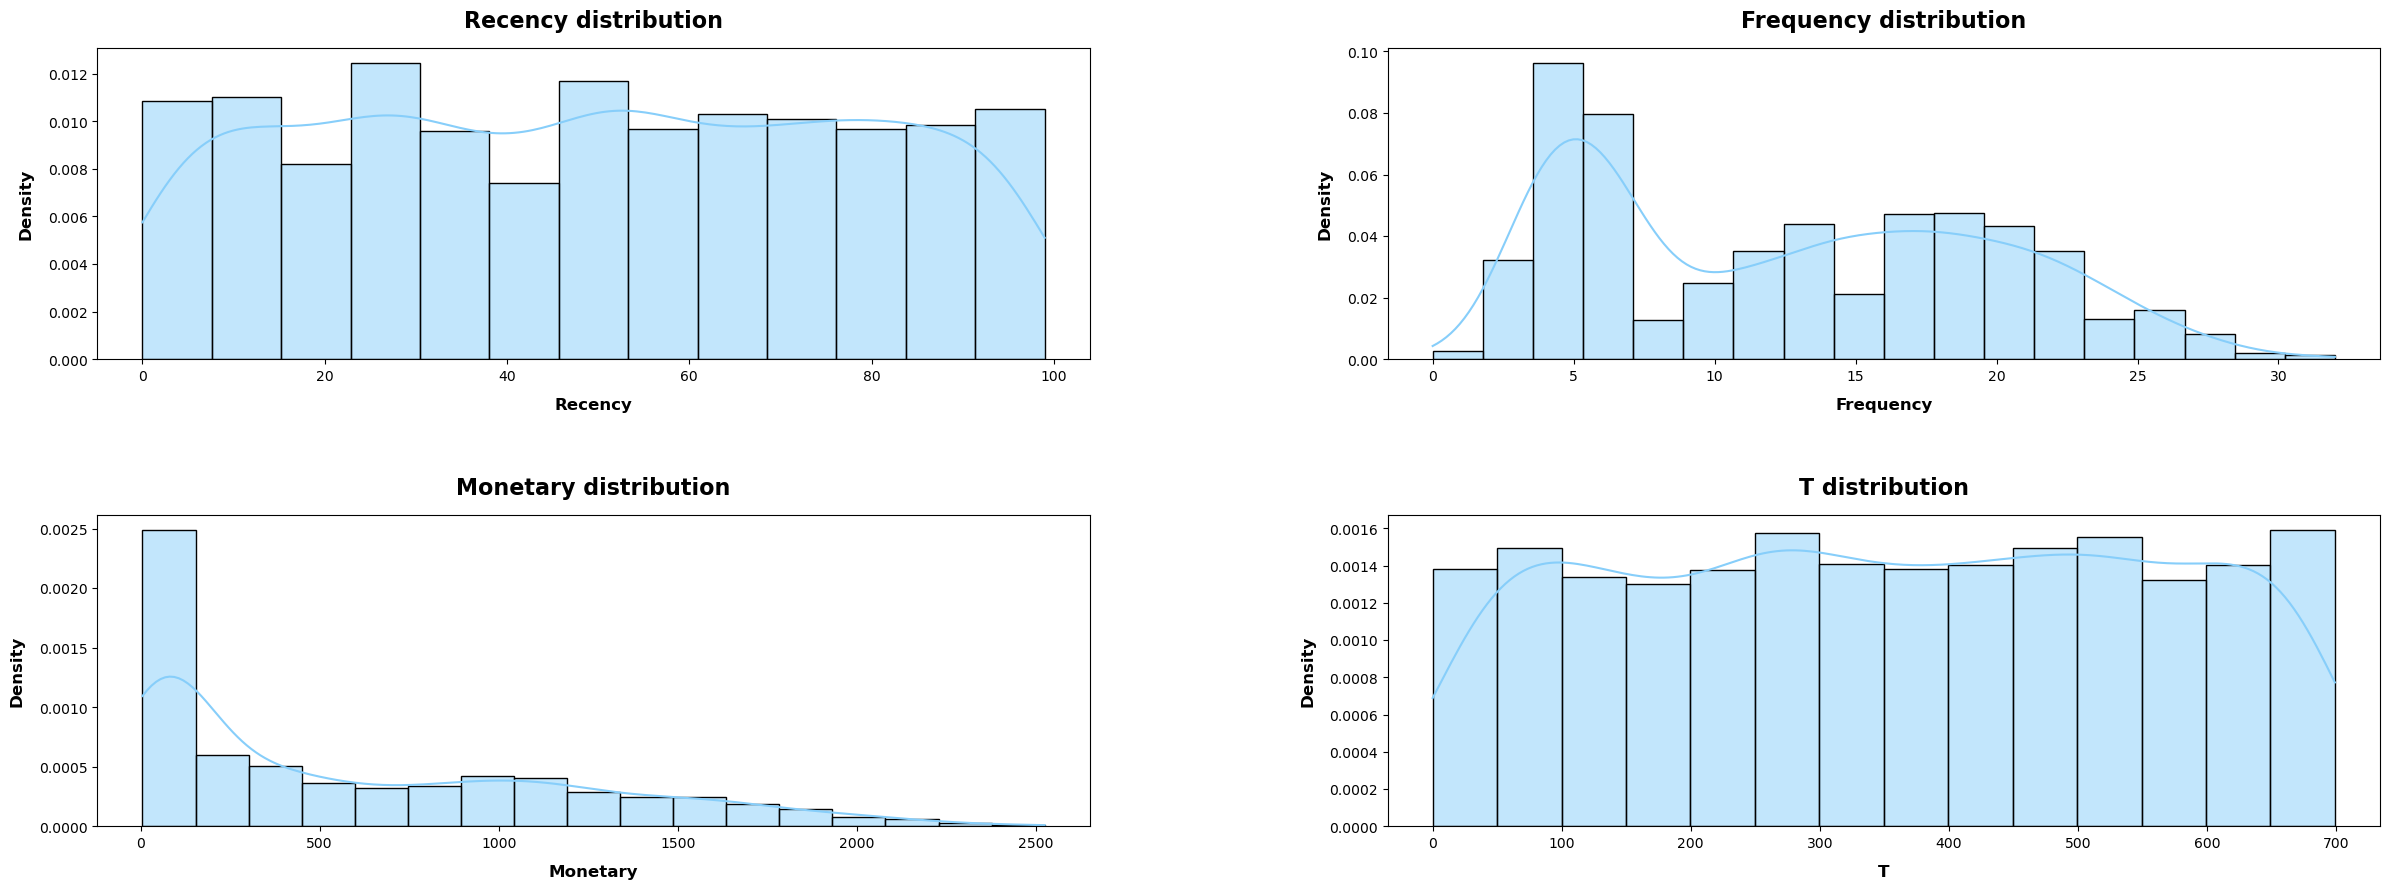

In [93]:
# plotting distriution of RFM-T features
fig, ax = plt.subplots(2, 2, figsize=(24, 9))
ax=ax.flatten()
for i, col in enumerate(['Recency', 'Frequency', 'Monetary', 'T']):
    sns.histplot(data=customer_df, x=col, stat='density', kde=True, color='lightskyblue', ax=ax[i])
    ax[i].set_title(f"{col} distribution", fontsize=16, fontweight='bold', y=1.04)
    ax[i].set_xlabel(f"{col}", fontsize=12, fontweight='bold', labelpad=10)
    ax[i].set_ylabel('Density', fontsize=12, fontweight='bold', labelpad=10)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.5)
plt.show()


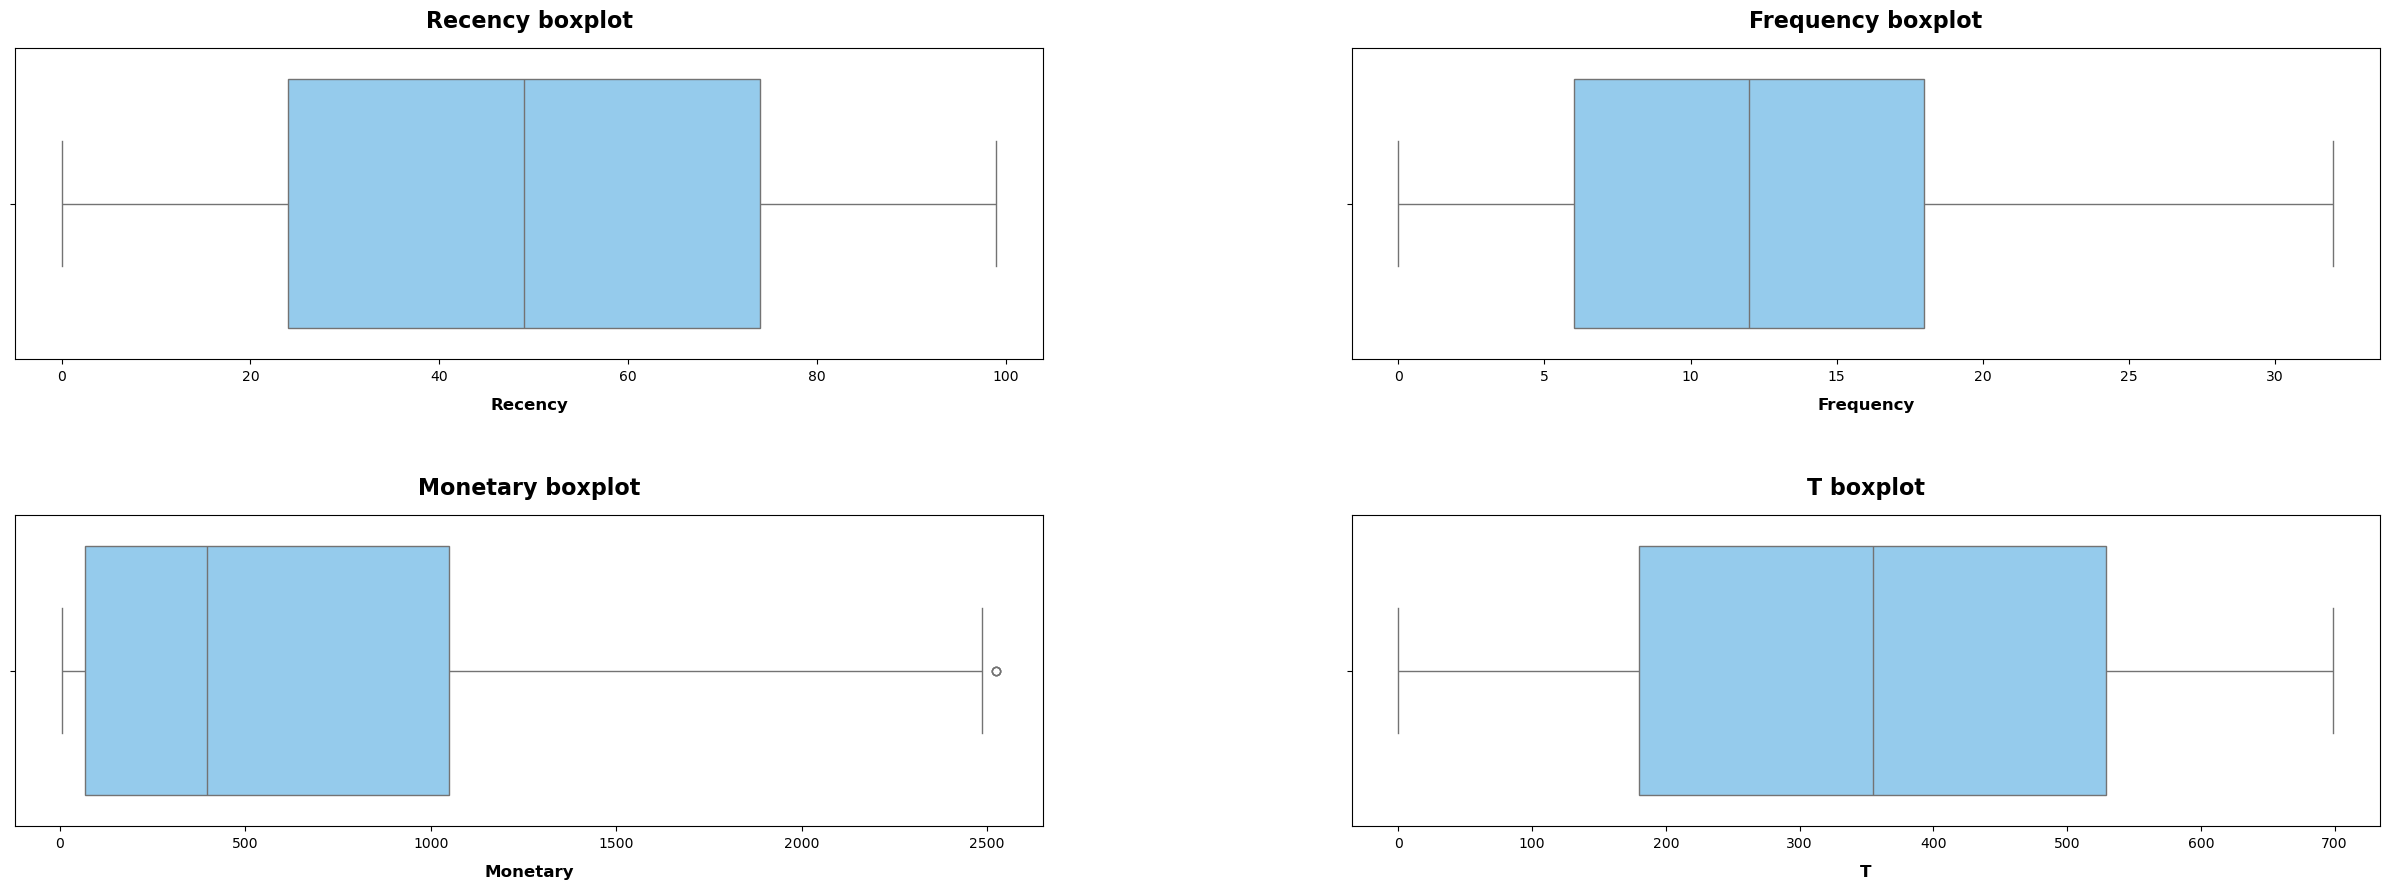

In [94]:
# plotting distriution of RFM-T features
fig, ax = plt.subplots(2, 2, figsize=(24, 9))
ax=ax.flatten()
for i, col in enumerate(['Recency', 'Frequency', 'Monetary', 'T']):
    sns.boxplot(data=customer_df, x=col, color='lightskyblue', ax=ax[i])
    ax[i].set_title(f"{col} boxplot", fontsize=16, fontweight='bold', y=1.04)
    ax[i].set_xlabel(f"{col}", fontsize=12, fontweight='bold', labelpad=10)
    #ax[i].set_ylabel('Density', fontsize=12, fontweight='bold', labelpad=10)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.5)
plt.show()


In [95]:
rfm_df.describe()

,ID,Recency,Frequency,Monetary,T
count,2214.000000,2214.000000,2214.000000,2214.000000,2214.000000
mean,5588.462511,49.032520,12.565041,607.547425,353.486902
std,3248.656750,28.953612,7.202705,602.967666,202.522900
min,0.000000,0.000000,0.000000,5.000000,0.000000
25%,2817.750000,24.000000,6.000000,69.000000,180.000000
50%,5458.500000,49.000000,12.000000,397.000000,355.000000
75%,8419.500000,74.000000,18.000000,1048.000000,529.000000
max,11191.000000,99.000000,32.000000,2525.000000,699.000000


In [96]:
#checking for the values containing zero.

print(f"Total Number of Frequency with 0 : {len(rfm_df[rfm_df["Frequency"] == 0])}")
print(f"Total Number of Recency with 0 : {len(rfm_df[rfm_df["Recency"] == 0])}")
print(f"Total Number of Monetary Value with 0 : {len(rfm_df[rfm_df["Monetary"] == 0])}")


Total Number of Frequency with 0 : 6
Total Number of Recency with 0 : 28
Total Number of Monetary Value with 0 : 0


In this project, CLV is predicted at the customer level rather than at the cohort or aggregate level. This approach allows us to capture individual customer behavior for more personalized insights.



#### **2.1. Beta Geo - Negative Binomial Distribution + Gamma Gamma Distribution Model (BG/NBD)**


##### **2.1.1. Beta Geo - Negative Binomial Distribution**

__NOTE__ : Make sure your dataset only includes **repeat customers (Frequency > 1)** and that the BG/NBD assumptions hold **(Recency ≤ Tenure)**, you should filter accordingly before fitting the model.


In [97]:
# Exclude one-time buyers
data = rfm_df[rfm_df['Frequency'] >1].copy()

# Ensure Recency <= Tenure
df = data[data['Recency'] <= data['T']]

# Fit BG/NBD model --- this model learns from the customers who repeat purchase, time of last purchase, total time a customer has been observed
bg_model = BetaGeoFitter(penalizer_coef=0.01)
bg_model.fit(df['Frequency'], df['Recency'], df['T'])
print(bg_model) # these parameters describe customer purchasing behaviour


<lifetimes.BetaGeoFitter: fitted with 2061 subjects, a: 0.69, alpha: 0.57, b: 3.51, r: 0.54>


In [98]:
display(bg_model.summary)

,coef,se(coef),lower 95% bound,upper 95% bound
r,0.537674,0.018763,0.500898,0.574450
alpha,0.566979,0.038866,0.490801,0.643157
a,0.689618,0.019506,0.651387,0.727849
b,3.513356,0.102142,3.313157,3.713555


- **Beta distribution** : captures __heterogeneity in dropout rates__ (how likely customers are to stop buying) & **(ρ) denotes the dropout probability so, values lies between [0, 1]**.
    - Some customers are more likely to stop buying quickly, others stay longer.


- **Gamma distribution** : captures __heterogeneity in purchase rates__ (how often customers buy) & **(λ) denotes the purchase rate & it takes values on non-negative real line: x >= 0 i.e, x in [0, infinity)**.
    - Some buy very frequently, others rarely.



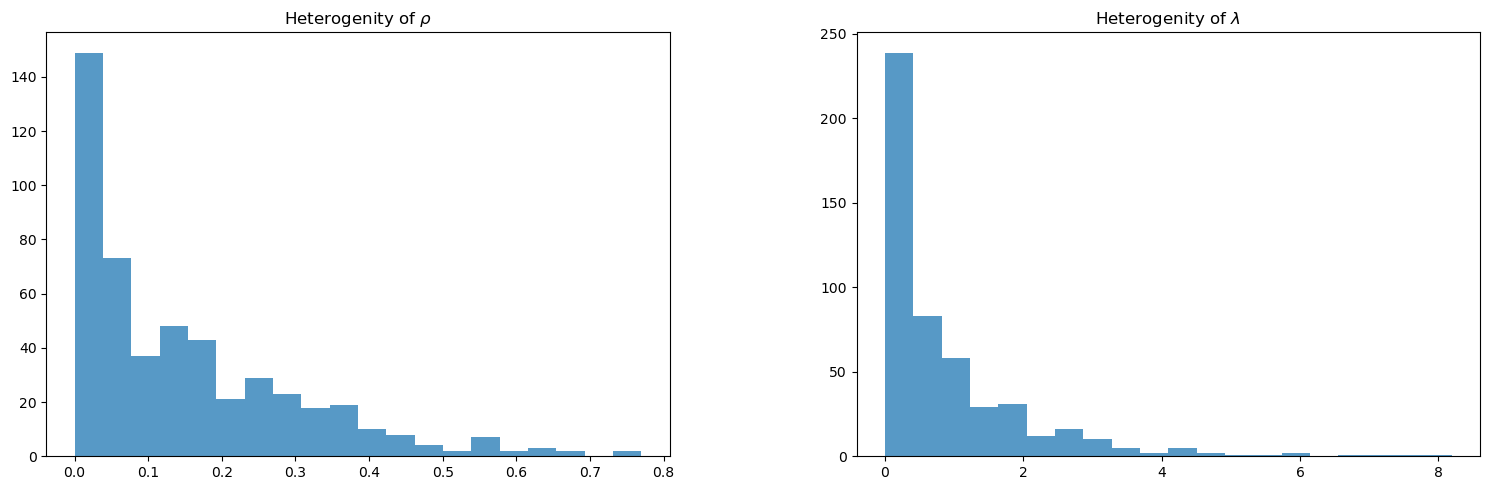

In [99]:
from scipy.stats import gamma, beta

# Plot
beta_dist = beta.rvs(bg_model.params_['a'], bg_model.params_['b'], size = 500)
gamma_dist = gamma.rvs(bg_model.params_['r'], scale=1./bg_model.params_['alpha'], size = 500)

fig, ax = plt.subplots(1, 2, figsize=(15,5))

ax[0].set_title(r'Heterogenity of $\rho$')
ax[0].hist(beta_dist, bins=20, alpha=0.75)

ax[1].set_title(r'Heterogenity of $\lambda$')
ax[1].hist(gamma_dist, bins=20, alpha=0.75)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()


**Visualizing frequency/recency matrix**

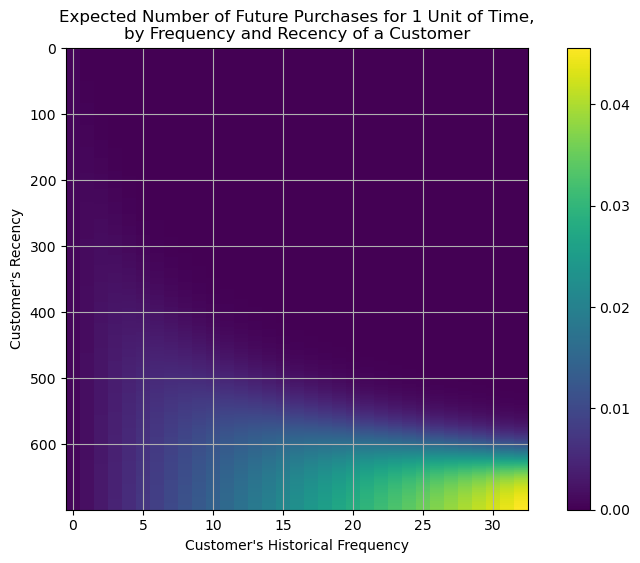

In [100]:

# plotting the frequency & recency matrix (computes the expected number of transactions a customer is to make in the next time period, given the R(age at last purchase) and F (the number of repeat transactions made))
plt.figure(figsize=(10, 6))
plot_frequency_recency_matrix(bg_model)

plt.grid(axis='both')
plt.show()


- Low frequency : The customer has made only a few purchases.

- High frequency : The customer has made many purchases.

- Low recency : Their last purchase was a long time ago (they haven't bought recently).

- High recency : Their last purchase was very recent.

**Insights:**

**Bottom-right: High frequency + High recency**
Example: 30 purchases, last purchase at 600+ days  
-> These are __best customers__. They buy often and recently, so they are highly engaged and loyal.
- **Business action:** Reward them with loyalty programs, exclusive offers, or VIP treatment to retain them.

**Top-right: High frequency + Low recency**  
-> Customers who used to buy a lot but haven't purchased in a long time. They may have **churned**.
- **Business action**: Run win-back campaigns (personalized emails, discounts, reactivation offers) to bring them back.

**Middle zone: Moderate frequency + Moderate recency**  
Example: around (15, 300)  
-> Customers who buy occasionally and haven't been seen recently. They might still be active, just between purchases.
- **Business action**: Nudge them with reminders, seasonal promotions, or product recommendations to encourage another purchase.

**Top-left: Low frequency + Low recency**  
-> Customers who bought once or very rarely, long ago. Least likely to return.
- **Business action**: Minimal investment; consider excluding them from expensive campaigns, but keep them in low-cost channels.


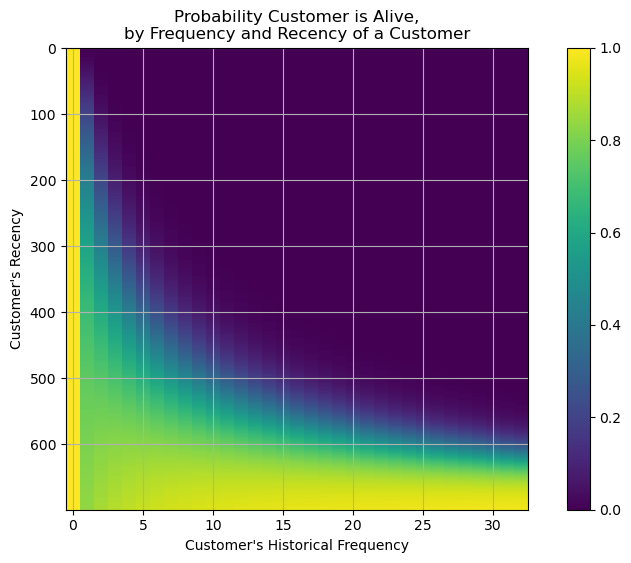

In [101]:

# plotting the churn matrix/ probability of active customer
plt.figure(figsize=(10, 6))
plot_probability_alive_matrix(bg_model)

plt.grid(axis='both')
plt.show()

**Key Findings :**

- **High recency (recent purchase)** -> Probability alive is close to 1.0.
    - These customers are almost surely `alive` because the model assumes that if they bought recently, they are still active.

- **High frequency + Low recency (long time since last purchase) → Probability alive drops sharply.**

Surprisingly, the more they bought in the past, the more likely the model assumes they've dropped out if they suddenly stop. This is because a loyal customer's absence is a stronger signal of churn than a casual buyer's absence.


__Key takeaway__

- **Recency dominates**: recent activity is the strongest predictor of being alive.

- **Frequency amplifies churn signals**: if a heavy buyer stops, it's more alarming than if a light buyer stops.


**Ranking customers from best to worst**

We can rank our customers by who is expected to make the most purchases in the next period, down to those expected to make the least. The model uses each customer's purchase history to predict their future buying activity.

In [102]:
# Customers expected to make the most purchases in 3 months
df['Predicted_purchases'] = bg_model.conditional_expected_number_of_purchases_up_to_time(3*30,
                                                    df['Frequency'],
                                                    df['Recency'],
                                                    df['T'])
df['Predicted_purchases'] = df['Predicted_purchases'].map(lambda x: f"{x:.4f}").astype('float')
display(df.sort_values(by = "Predicted_purchases", ignore_index=True).tail(10))


,ID,Recency,Frequency,Monetary,T,Predicted_purchases
2051,1584,79,14,482,89,9.4333
2052,5558,90,14,1685,90,11.0680
2053,3830,59,15,459,66,12.8968
2054,2963,56,20,1440,58,21.4716
2055,7723,56,20,1440,58,21.4716
2056,10767,40,20,1346,44,23.0994
2057,2546,7,5,70,7,23.4821
2058,6892,23,20,732,26,29.5427
2059,9888,3,15,1091,4,29.8796
2060,4399,3,15,1091,4,29.8796


Based on the above analysis, above are the top 10 customers expected to make the most purchases in the next 3 months.

**Insight :**

This approach helps identify **high-value customers** who are most likely to buy again soon. Companies can then focus campaigns, loyalty programs, or personalized offers on these customers to maximize ROI.

**Assessing Model Fit**

To evaluate the accuracy of our model, the first step is to compare the actual customer data with artificial data generated using the parameters from our fitted model.

CPU times: total: 2.89 s
Wall time: 7.82 s


<Figure size 800x400 with 0 Axes>

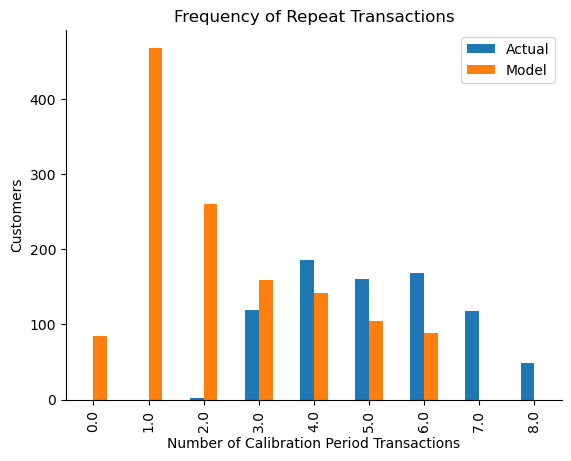

In [103]:
%%time
from lifetimes.plotting import plot_period_transactions

plt.figure(figsize=(8, 4))
ax = plot_period_transactions(bg_model, max_frequency=7)
#ax.set_yscale('log')
sns.despine();

This chart compares actual customer transaction frequencies with those predicted by the BG/NBD model during the calibration period.

**Interpretation**

- The x-axis shows how many repeat transactions customers made (from 0 to 8).

- The y-axis shows how many customers fall into each transaction count.

- Blue bars (Actual) represent real observed data.

- Orange bars (Model) represent simulated data generated using the fitted model's parameters.

**Insights**

- For low-frequency customers (0–2 transactions), the model overestimates compared to actual data — it predicts more customers with few purchases than observed.

- For mid-range frequencies (3–6 transactions), the model's predictions are closer to reality, showing good calibration.

- For high-frequency customers (7–8 transactions), the model underestimates — fewer customers are predicted than actually observed.

**What This Means**

- The model captures general purchasing behavior but struggles slightly at the extremes — it's too optimistic for infrequent buyers and too conservative for heavy buyers.

- This comparison helps assess model correctness by showing how well simulated data matches real-world patterns.


In [104]:
# Creating a function which can predict the future purchased value based on the specific period
def bg_model_prediction(t, id_):
    # select single row
    individual_row = df[df['ID']==id_].iloc[0]
    
    # predict the next purchase  in time t
    individual_pred = bg_model.predict(t, individual_row['Frequency'], individual_row['Recency'], individual_row['T'])
    
    # Actual value
    actual_value = (individual_row['Frequency']/individual_row['Recency'])*t
    
    # Error
    error = actual_value - individual_pred

    print(f"Your Predicted Purchase : {individual_pred:.4f}")
    print(f"Your Actual Purchase : {actual_value:.4f}")
    print(f"Prediction Error : {error:.4f}")


# Apply on some customer id
(bg_model_prediction(90, 5524))
print()
print("*"*40, end="\n\n")
(bg_model_prediction(90, 2963))

Your Predicted Purchase : 0.0000
Your Actual Purchase : 34.1379
Prediction Error : 34.1379

****************************************

Your Predicted Purchase : 21.4716
Your Actual Purchase : 32.1429
Prediction Error : 10.6713


**Compute actual prediction**

In [105]:
df['Actual_90'] = ((df['Frequency']/df['Recency'])*90).map(lambda x: f"{x:.4f}").astype(float)

df = df.fillna(value = 0) #filling null values with 0

#calculating the prediction error for the 30 days purchase prediction
df["Error"] = df["Actual_90"] - df["Predicted_purchases"]

display(df.head())

,ID,Recency,Frequency,Monetary,T,Predicted_purchases,Actual_90,Error
0,5524,58,22,1617,663,0.0000,34.1379,34.1379
1,2174,38,4,27,113,0.2026,9.4737,9.2711
2,4141,26,20,776,312,0.0000,69.2308,69.2308
3,6182,26,6,53,139,0.0009,20.7692,20.7683
4,5324,94,14,422,161,0.0693,13.4043,13.3350


In [106]:
from sklearn.metrics import mean_squared_error
df = df.replace([np.inf, -np.inf], np.nan).fillna(0)
mse = mean_squared_error(df['Actual_90'], df['Predicted_purchases'])

print(f"Mean Squared Error : {mse:.4f}")
print(f"Average Error : {df["Error"].mean():.4f}")
print(f"Root Mean Squared Error : {np.sqrt(mse):.4f}")



Mean Squared Error : 31191.7169
Average Error : 63.3975
Root Mean Squared Error : 176.6118


**Note:** 

This error is based on the 90 days window period, it may vary as you adjust the window period.

##### **2.1.2. Gamma Gamma Distribution Model**

The **Gamma-Gamma model** estimates the **average profit per transaction** for each customer, and when combined with the **BG/NBD model's prediction of future purchases**, it allows us to calculate the **expected customer lifetime value (CLTV) over a chosen period**.

__NOTE__ : Make sure your dataset only includes **repeat customers (Frequency > 0)** .


In [107]:
df_summary = df[df['Frequency']>0]
display(df_summary.head())
print()
print('\nCustomers with atleast 1 repeat purchase\n', len(df_summary))


,ID,Recency,Frequency,Monetary,T,Predicted_purchases,Actual_90,Error
0,5524,58,22,1617,663,0.0000,34.1379,34.1379
1,2174,38,4,27,113,0.2026,9.4737,9.2711
2,4141,26,20,776,312,0.0000,69.2308,69.2308
3,6182,26,6,53,139,0.0009,20.7692,20.7683
4,5324,94,14,422,161,0.0693,13.4043,13.3350




Customers with atleast 1 repeat purchase
 2061


**Compute Average Profit Per Transaction using Gamam-Gamma Approach**

In [108]:
# model fits in average sales per transaction 
df_summary.loc[:,'Avg_Monetary'] = df_summary['Monetary'] / df_summary['Frequency']
ggf_model = GammaGammaFitter(penalizer_coef = 0.01)
ggf_model.fit(df_summary['Frequency'], df_summary['Avg_Monetary'])

df_summary['Predicted_Avg_Sales'] = ggf_model.conditional_expected_average_profit(df_summary['Frequency'],df_summary['Avg_Monetary'])
df_summary.head()

,ID,Recency,Frequency,Monetary,T,Predicted_purchases,Actual_90,Error,Avg_Monetary,Predicted_Avg_Sales
0,5524,58,22,1617,663,0.0000,34.1379,34.1379,73.500000,73.803464
1,2174,38,4,27,113,0.2026,9.4737,9.2711,6.750000,7.690222
2,4141,26,20,776,312,0.0000,69.2308,69.2308,38.800000,39.057202
3,6182,26,6,53,139,0.0009,20.7692,20.7683,8.833333,9.473252
4,5324,94,14,422,161,0.0693,13.4043,13.3350,30.142857,30.483283


In [109]:
print(f"Predicted Average Sales: {df_summary["Predicted_Avg_Sales"].mean()}")
print(f"Actual Average Sales: {df_summary["Avg_Monetary"].mean()}")
print(f"Difference: {df_summary["Avg_Monetary"].mean() - df_summary["Predicted_Avg_Sales"].mean()}")
print(f"Mean Squared Error: {mean_squared_error(df_summary["Avg_Monetary"], df_summary["Predicted_Avg_Sales"])}")
print(f"Root Mean Squared Error: {sqrt(mean_squared_error(df_summary["Avg_Monetary"], df_summary["Predicted_Avg_Sales"]))}")
      

Predicted Average Sales: 38.23628236997558
Actual Average Sales: 37.691390339929974
Difference: -0.5448920300456024
Mean Squared Error: 0.39553055527500014
Root Mean Squared Error: 0.6289121999730966


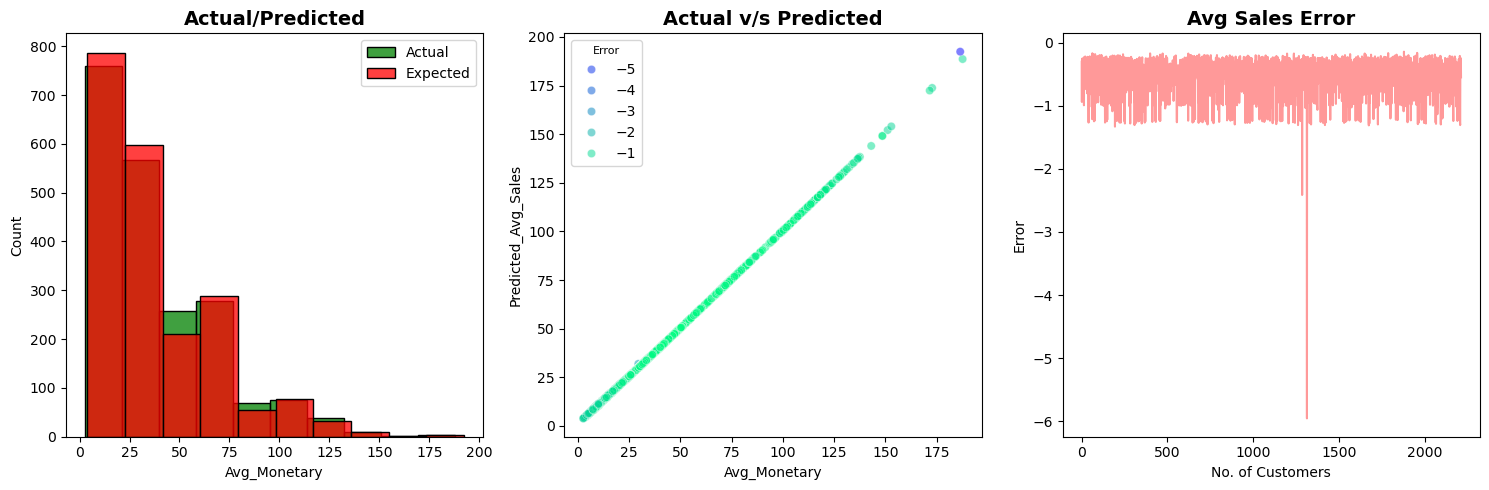

In [110]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(df_summary["Avg_Monetary"], color = "g", bins=10, kde = False, ax = ax[0])
sns.histplot(df_summary["Predicted_Avg_Sales"], color = "r", bins=10, kde = False, ax=ax[0])
ax[0].set_title("Actual/Predicted", fontsize=14, fontweight='bold')
ax[0].legend(["Actual", "Expected"])

error = df_summary["Avg_Monetary"]-df_summary["Predicted_Avg_Sales"]
sns.scatterplot(data=df_summary, x="Avg_Monetary", y="Predicted_Avg_Sales", alpha = 0.5, hue =error, palette = "winter",ax=ax[1])
ax[1].set_title("Actual v/s Predicted", fontsize=14, fontweight='bold')
ax[1].legend(title='Error', title_fontsize=8)

ax[2].plot(error, color = 'r', alpha = 0.4)
ax[2].set_title("Avg Sales Error", fontsize=14, fontweight='bold')
ax[2].set_xlabel('No. of Customers')
ax[2].set_ylabel('Error')

plt.tight_layout()
plt.subplots_adjust(hspace=0.1)
plt.show()

**Compute CLTV using Gamma-Gamma Model**

In [111]:

# The customers' lifetime values expected to in the next 3 months
bg_model.fit(df_summary['Frequency'], df_summary['Recency'], df_summary['T'])
df_summary['Predicted_cltv'] = ggf_model.customer_lifetime_value(
    bg_model,  # the model to use to predict the number of future transactions
    df_summary['Frequency'],df_summary['Recency'],df_summary['T'],df_summary['Avg_Monetary'],
    time=3,  #3 months
    freq="M",  #frequency information of T. In this case we set week by using 'D'
    discount_rate=0.01).map(lambda x: f"{x:.2f}").astype(float)

display(df_summary.head())

,ID,Recency,Frequency,Monetary,T,Predicted_purchases,Actual_90,Error,Avg_Monetary,Predicted_Avg_Sales,Predicted_cltv
0,5524,58,22,1617,663,0.0000,34.1379,34.1379,73.500000,73.803464,0.00
1,2174,38,4,27,113,0.2026,9.4737,9.2711,6.750000,7.690222,0.06
2,4141,26,20,776,312,0.0000,69.2308,69.2308,38.800000,39.057202,0.00
3,6182,26,6,53,139,0.0009,20.7692,20.7683,8.833333,9.473252,0.00
4,5324,94,14,422,161,0.0693,13.4043,13.3350,30.142857,30.483283,0.08


In [112]:
#  Manual predict clv = Predicted no. of transactions * Expected avg sales * profit_margin to compute profit from each transaction
profit_margin = 0.05
df_summary['Manual_Predicted_cltv'] = (df_summary['Predicted_purchases'] * df_summary['Predicted_Avg_Sales'] * profit_margin).map(lambda x: f"{x:.2f}").astype(float)
df_summary.head()

,ID,Recency,Frequency,Monetary,T,Predicted_purchases,Actual_90,Error,Avg_Monetary,Predicted_Avg_Sales,Predicted_cltv,Manual_Predicted_cltv
0,5524,58,22,1617,663,0.0000,34.1379,34.1379,73.500000,73.803464,0.00,0.00
1,2174,38,4,27,113,0.2026,9.4737,9.2711,6.750000,7.690222,0.06,0.08
2,4141,26,20,776,312,0.0000,69.2308,69.2308,38.800000,39.057202,0.00,0.00
3,6182,26,6,53,139,0.0009,20.7692,20.7683,8.833333,9.473252,0.00,0.00
4,5324,94,14,422,161,0.0693,13.4043,13.3350,30.142857,30.483283,0.08,0.11


In [113]:
# actual spend in 3 months
actual =  df_summary['Avg_Monetary'] * df_summary['Actual_90']

# predicted spend in 3 months
predicted = df_summary['Predicted_purchases'] * df_summary['Predicted_Avg_Sales']

# Error
error = actual - predicted

# create dataframe
result = pd.DataFrame([actual, predicted, error], index = ["Actual", "Predicted", "Error"]).T
result.head()

,Actual,Predicted,Error
0,2509.135650,0.000000,2509.135650
1,63.947475,1.558039,62.389436
2,2686.155040,0.000000,2686.155040
3,183.461267,0.008526,183.452741
4,404.043900,2.112492,401.931408


In [114]:
print(f"Average Error: {result["Error"].mean()}")
print(f"Mean Squared Error: {mean_squared_error(result["Actual"], result["Predicted"])}")
print(f"Root Mean Squared Error: {sqrt(mean_squared_error(result["Actual"], result["Predicted"]))}")


Average Error: 3182.7555746760295
Mean Squared Error: 126129816.51413925
Root Mean Squared Error: 11230.753158810821


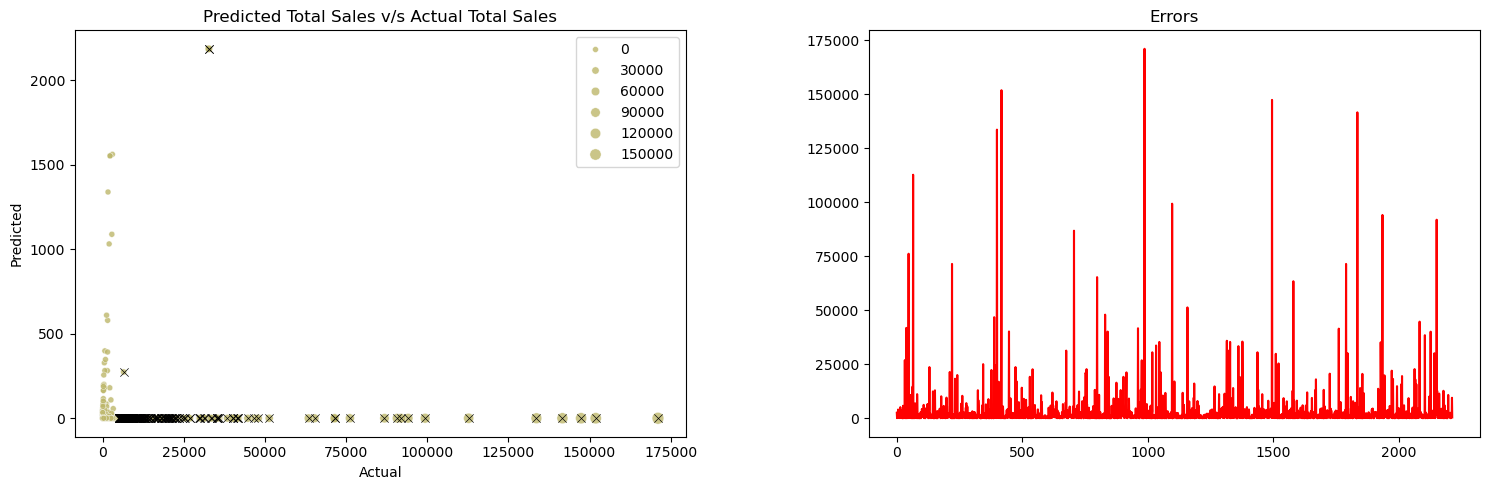

In [115]:
#Predicted v/s Actual
fig, ax = plt.subplots(1, 2, figsize=(15,5))

sns.scatterplot(data=result, x="Actual", y="Predicted", size = "Error", color = "darkkhaki", alpha = 0.8, marker = 'o', ax=ax[0])
sns.scatterplot(x = result[result["Error"] > 5000]["Actual"], y=result[result["Error"] > 5000]["Predicted"], data=result, color = "k", marker = "x", ax=ax[0])
ax[0].set_title("Predicted Total Sales v/s Actual Total Sales")

ax[1].plot(result["Error"], color = "r")
ax[1].set_title("Errors")

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()


In [116]:
print(df_summary['Predicted_cltv'].value_counts().nlargest(2))
print("\n"+"*"*20+ "*"*20, end="\n")
print(df_summary['Manual_Predicted_cltv'].value_counts().nlargest(2))

Predicted_cltv
0.00    1774
0.01      52
Name: count, dtype: int64

****************************************
Manual_Predicted_cltv
0.00    1749
0.01      65
Name: count, dtype: int64


Since most of the CLV scores are zero, we categorize customers into two groups: 

- **Profitable** (those with predicted CLTV greater than zero) 
- **Non-Profitable** (those with predicted CLTV equal to zero).


In [117]:
df_summary['CLV_label'] = df_summary['Predicted_cltv']>0
df_summary['CLV_label'] = df_summary['CLV_label'].map({True:'Profitable', False:'Non-profitable'})
df_summary.head()


,ID,Recency,Frequency,Monetary,T,Predicted_purchases,Actual_90,Error,Avg_Monetary,Predicted_Avg_Sales,Predicted_cltv,Manual_Predicted_cltv,CLV_label
0,5524,58,22,1617,663,0.0000,34.1379,34.1379,73.500000,73.803464,0.00,0.00,Non-profitable
1,2174,38,4,27,113,0.2026,9.4737,9.2711,6.750000,7.690222,0.06,0.08,Profitable
2,4141,26,20,776,312,0.0000,69.2308,69.2308,38.800000,39.057202,0.00,0.00,Non-profitable
3,6182,26,6,53,139,0.0009,20.7692,20.7683,8.833333,9.473252,0.00,0.00,Non-profitable
4,5324,94,14,422,161,0.0693,13.4043,13.3350,30.142857,30.483283,0.08,0.11,Profitable


In [118]:
# create CLV_label for customer_seg_df as well
customer_seg_df = customer_seg_df[customer_seg_df['Frequency'] >= 1].copy()
customer_seg_df['CLV_label'] = df_summary['Predicted_cltv']>0
customer_seg_df['CLV_label'] = customer_seg_df['CLV_label'].map({True:'Profitable', False:'Non-profitable'})
display(customer_seg_df.head())


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Is_parent,Children,Day,Month,Quarter,Year,Tenure,Cluster,Recency,Monetary,Frequency,R,F,M,RFM_Score,Segment,CLV_label
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,58,0,0,4,9,3,2012,28,1,58,73.500000,22,3,5,5,355,Loyal Customers,Non-profitable
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,61,1,2,8,3,1,2014,9,0,38,6.750000,4,4,1,1,411,Promising,Profitable
2,4141,1965,Graduation,Partner,71613.0,0,0,2013-08-21,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,50,0,0,21,8,3,2013,16,2,26,38.800000,20,4,4,4,444,Loyal Customers,Non-profitable
3,6182,1984,Graduation,Partner,26646.0,1,0,2014-02-10,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,31,1,1,10,2,1,2014,10,0,26,8.833333,6,4,2,1,421,Potential Loyalists,Non-profitable
4,5324,1981,PhD,Partner,58293.0,1,0,2014-01-19,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,34,1,1,19,1,1,2014,11,2,94,30.142857,14,1,3,3,133,At risk,Profitable


## **3. Profiling**

After forming the customer segments, we analyzed their purchasing behaviors. Next, we profile each segment to understand who our most valuable customers are — the `star` group — and which customers require more attention and engagement from the store.


**3.1. Distribution of CLV**

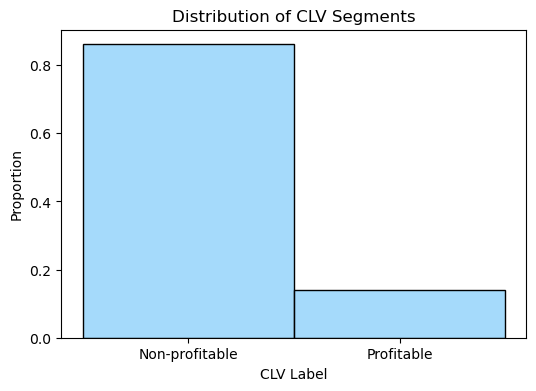

In [119]:
plt.figure(figsize=(6,4))
sns.histplot(
    data=customer_seg_df,
    x="CLV_label",
    stat="probability",
    color="lightskyblue",
    discrete=True   # ensures proper handling of categorical values
)
plt.title("Distribution of CLV Segments")
plt.xlabel("CLV Label")
plt.ylabel("Proportion")
plt.show()


- **14% customers drive profit.**

**3.2. Complain vs Segment & Complain vs CLV Label**

In [120]:
customer_seg_df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'Age',
       'Is_parent', 'Children', 'Day', 'Month', 'Quarter', 'Year', 'Tenure',
       'Cluster', 'Recency', 'Monetary', 'Frequency', 'R', 'F', 'M',
       'RFM_Score', 'Segment', 'CLV_label'],
      dtype='object')

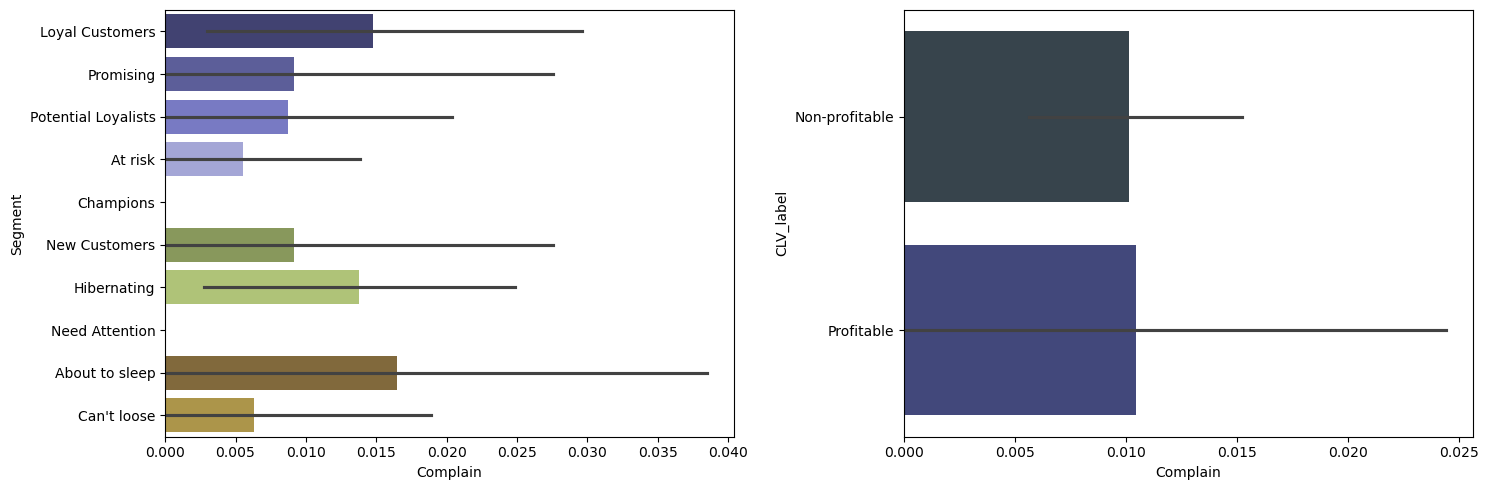

In [121]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(x='Complain', y='Segment', data=customer_seg_df, palette='tab20b', ax=ax[0]);

sns.barplot(y='CLV_label', x='Complain', data=customer_seg_df, palette=['#334550','#394184'], ax=ax[1])

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.5)
plt.show()


- **There are equal numbers of complain from profitable & non-profitable customers.**

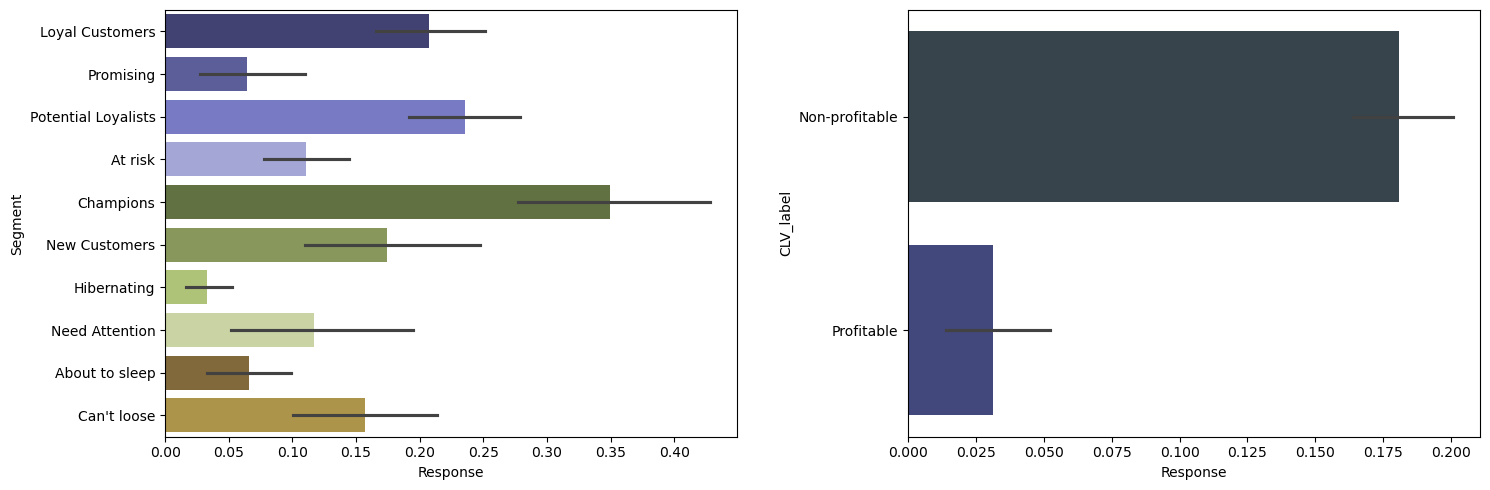

In [122]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(x='Response', y='Segment', data=customer_seg_df, palette='tab20b', ax=ax[0]);

sns.barplot(y='CLV_label', x='Response', data=customer_seg_df, palette=['#334550','#394184'], ax=ax[1])

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.5)
plt.show()


- **The marketing campaign is working, and we can create better offers for our loyal, loyalist, and consistent customers.**

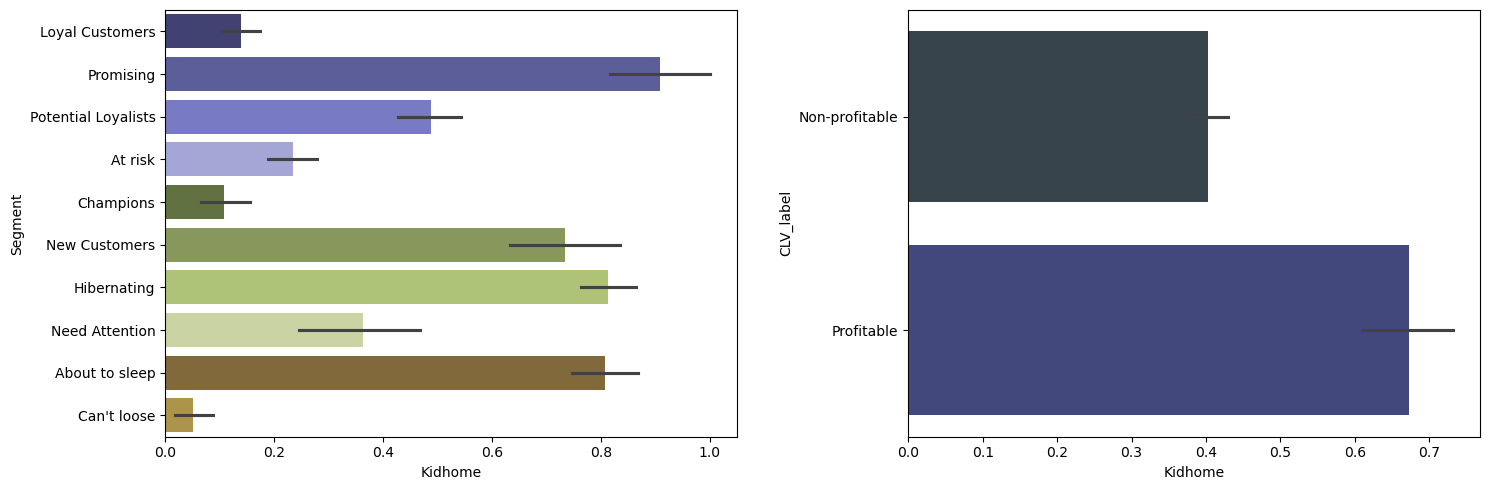

In [123]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(x='Kidhome', y='Segment', data=customer_seg_df, palette='tab20b', ax=ax[0]);

sns.barplot(y='CLV_label', x='Kidhome', data=customer_seg_df, palette=['#334550','#394184'], ax=ax[1])

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.5)
plt.show()


- **Our most profitable customers tend to have children at home, so we should increase targeted advertising aimed at parents.**

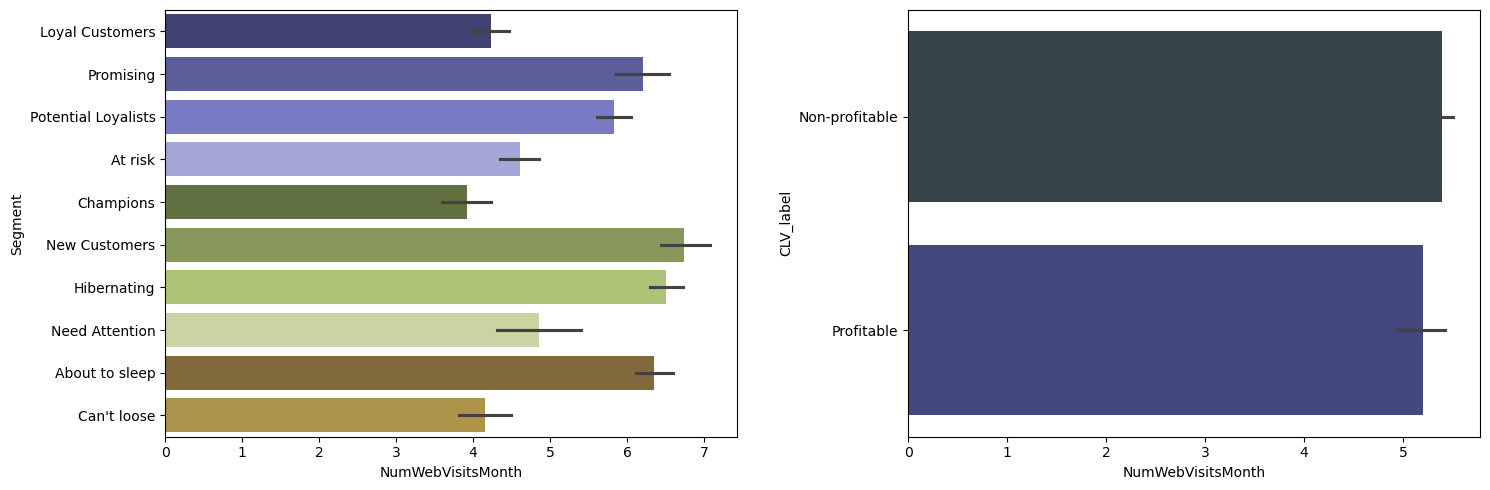

In [124]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(x='NumWebVisitsMonth', y='Segment', data=customer_seg_df, palette='tab20b', ax=ax[0]);

sns.barplot(y='CLV_label', x='NumWebVisitsMonth', data=customer_seg_df, palette=['#334550','#394184'], ax=ax[1])

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.5)
plt.show()


#### **4.1. Pareto - Negative Binomial Distribution + Gamma Gamma Distribution Model**

##### **4.1.1. Pareto - Negative Binomial Distribution**


In [125]:
# dataset for modelling
rfm_ = rfm_df.copy()
display_md(f"**Dataset Shape : {rfm_.shape}**")
display_md(f"**Duplicate observations : {rfm_.duplicated().sum()}**")

# Exclude one-time buyers
rfm_data = rfm_[rfm_['Frequency'] > 0].copy()

# Ensure Recency <= Tenure (assumption of Pareto/NBD before modelling)
rfm_pareto = rfm_data[rfm_data['Recency'] <= rfm_data['T']]

# Fit Pareto/NBD model --- this model learns from no. of repeat purchases, time b/w first and most recent purchase, total time a customer has been observed
pnbd_model = ParetoNBDFitter(
    penalizer_coef = 0.01
)

pnbd_model.fit(
    rfm_pareto['Frequency'],
    rfm_pareto['Recency'],
    rfm_pareto['T']
)

print(pnbd_model) # these parameters describe customer purchasing behaviour


**Dataset Shape : (2214, 5)**

**Duplicate observations : 0**

<lifetimes.ParetoNBDFitter: fitted with 2065 subjects, alpha: 0.96, beta: 64.08, r: 0.89, s: 1.37>


In [126]:
display(pnbd_model.params_)


r         0.894841
alpha     0.958251
s         1.370728
beta     64.084907
dtype: float64

| Customer behavior | Distribution | Denoted by | Parameters |
|---|---|---|---|
| Purchase rate | Gamma distribution | λ | r, α |
| Dropout rate | Gamma distribution | μ | s, β |
| Individual purchase process | Poisson process | — | λ |
| Individual dropout process | Exponential distribution | — | μ |


$\lambda \sim \mathrm{Gamma}(r,\alpha)$

Simply means, **Gamma → captures heterogeneity in purchase rates; $\lambda$ denotes an individual customer's purchase rate.**



$\mu \sim \mathrm{Gamma}(s,\beta)$

Simply means, **Gamma → captures heterogeneity in dropout rates; $\mu$ denotes an individual customer's dropout rate.**


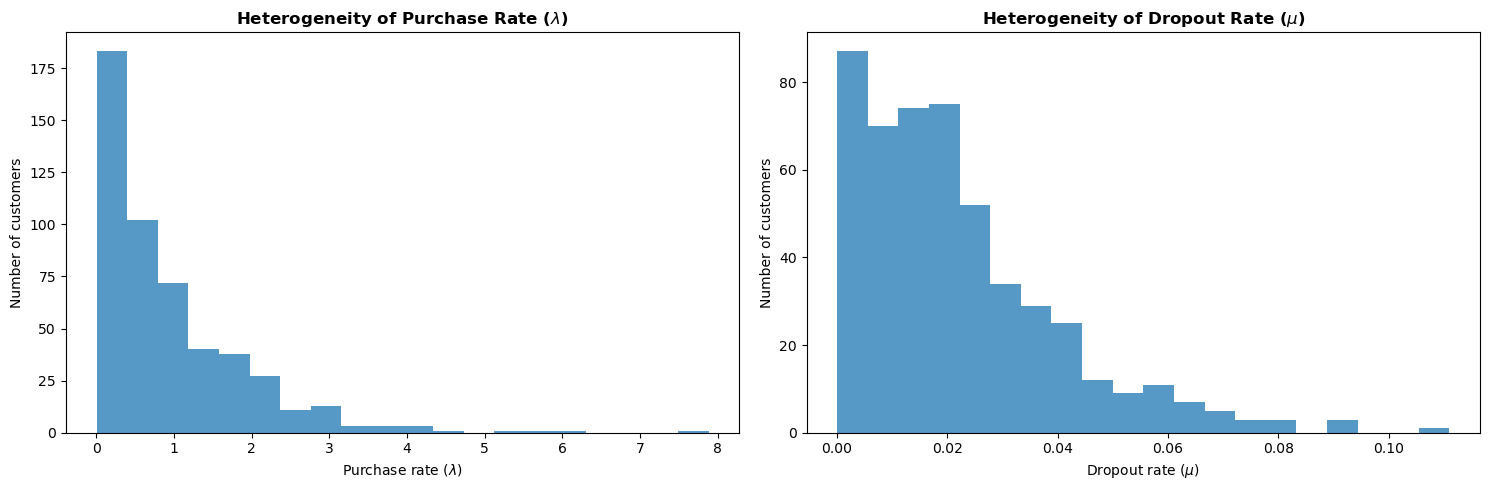

In [127]:
# Purchase-rate distribution
lambda_dist = gamma.rvs(
    a=pnbd_model.params_['r'],
    scale=1 / pnbd_model.params_['alpha'],
    size=500
)

# Dropout-rate distribution
mu_dist = gamma.rvs(
    a=pnbd_model.params_['s'],
    scale=1 / pnbd_model.params_['beta'],
    size=500
)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].set_title(r'Heterogeneity of Purchase Rate ($\lambda$)', fontsize=12, fontweight='bold')
ax[0].hist(lambda_dist, bins=20, alpha=0.75)
ax[0].set_xlabel(r'Purchase rate ($\lambda$)')
ax[0].set_ylabel('Number of customers')

ax[1].set_title(r'Heterogeneity of Dropout Rate ($\mu$)', fontsize=12, fontweight='bold')
ax[1].hist(mu_dist, bins=20, alpha=0.75)
ax[1].set_xlabel(r'Dropout rate ($\mu$)')
ax[1].set_ylabel('Number of customers')

plt.tight_layout()
plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.show()


**Visualizing frequency/recency matrix**

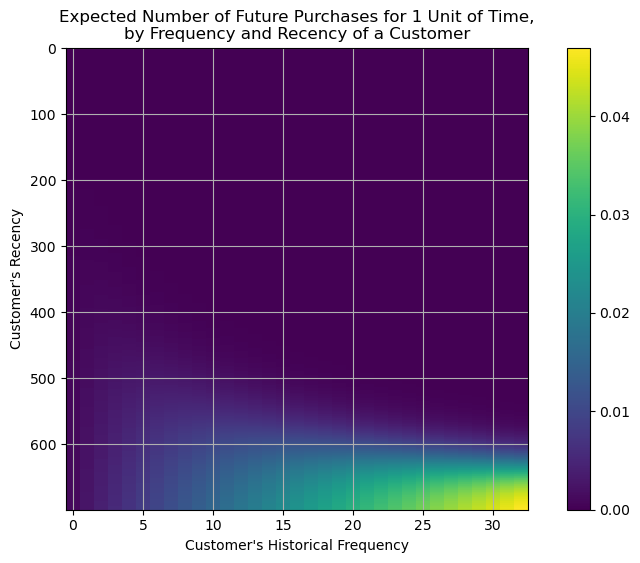

In [128]:
# plotting the frequency & recency matrix (computes the expected number of transactions a customer is to make in the next time period, given the R(age at last purchase) and F (the number of repeat transactions made))
plt.figure(figsize=(10, 6))
plot_frequency_recency_matrix(pnbd_model)

plt.grid(axis='both')
plt.show()


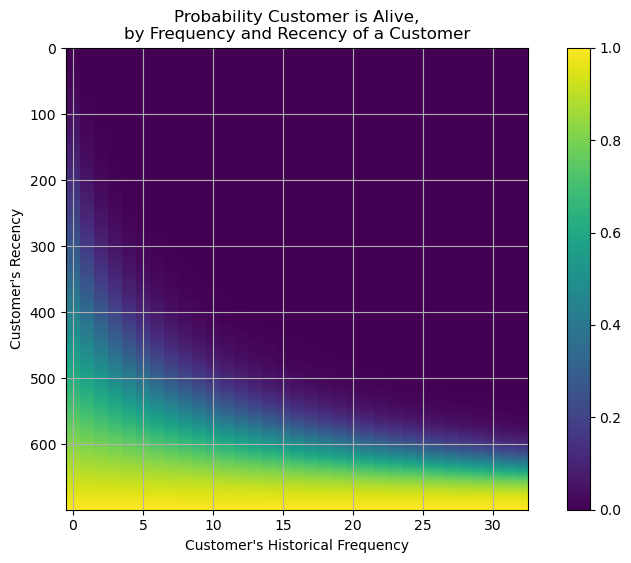

In [129]:
# plotting the churn matrix/ probability of active customer
plt.figure(figsize=(10, 6))
plot_probability_alive_matrix(pnbd_model)

plt.grid(axis='both')
plt.show()


In [130]:
# Compute probablity of alive of eachh customer
rfm_pareto['p_alive'] = pnbd_model.conditional_probability_alive(
    rfm_pareto['Frequency'],
    rfm_pareto['Recency'],
    rfm_pareto['T']
).round(4)

rfm_pareto['p_not_alive'] = 1 - pnbd_model.conditional_probability_alive(
    rfm_pareto['Frequency'],
    rfm_pareto['Recency'],
    rfm_pareto['T']
).round(4)

display(rfm_pareto.head())


,ID,Recency,Frequency,Monetary,T,p_alive,p_not_alive
0,5524,58,22,1617,663,0.0000,1.0000
1,2174,38,4,27,113,0.0226,0.9774
2,4141,26,20,776,312,0.0000,1.0000
3,6182,26,6,53,139,0.0001,0.9999
4,5324,94,14,422,161,0.0040,0.9960


**Ranking customers from best to worst**

In [131]:
# Customers expected to make the most purchases in 3 months
rfm_pareto['Predicted_purchases'] = pnbd_model.conditional_expected_number_of_purchases_up_to_time(3*30,
                                                    rfm_pareto['Frequency'],
                                                    rfm_pareto['Recency'],
                                                    rfm_pareto['T'])
rfm_pareto['Predicted_purchases'] = rfm_pareto['Predicted_purchases'].map(lambda x: f"{x:.4f}").astype('float')
display(rfm_pareto.sort_values(by = "Predicted_purchases", ignore_index=True).tail(10))


,ID,Recency,Frequency,Monetary,T,p_alive,p_not_alive,Predicted_purchases
2055,5558,90,14,1685,90,1.0000,0.0000,10.6713
2056,8566,10,3,9,14,0.8750,0.1250,11.8722
2057,3830,59,15,459,66,0.8228,0.1772,12.1391
2058,7723,56,20,1440,58,0.9675,0.0325,20.9059
2059,2963,56,20,1440,58,0.9675,0.0325,20.9059
2060,10767,40,20,1346,44,0.8594,0.1406,23.4236
2061,6892,23,20,732,26,0.8292,0.1708,35.3670
2062,2546,7,5,70,7,1.0000,0.0000,37.1555
2063,9888,3,15,1091,4,0.8402,0.1598,132.6767
2064,4399,3,15,1091,4,0.8402,0.1598,132.6767


Based on the analysis, these are the top 10 customers expected to make the most purchases in the next 3 months.


**Model Evaluation**


<Figure size 800x400 with 0 Axes>

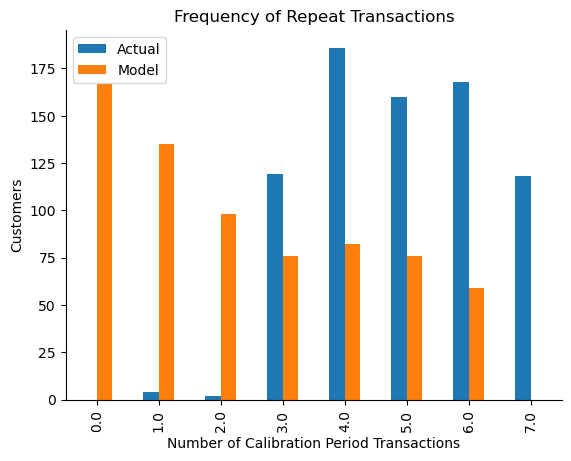

CPU times: total: 9.44 s
Wall time: 18.2 s


In [132]:
%%time

plt.figure(figsize=(8, 4))
ax = plot_period_transactions(pnbd_model, max_frequency=7)
sns.despine()
plt.show()


This chart compares actual customer purchase frequencies with those predicted by the Pareto/NBD model during the calibration period.

**Insights**

- Mid-range frequencies (3–6 transactions), the model's predictions are closer to reality, showing good calibration but low-frequeny(0-2) and high-frquency overestimates and underestimates respectively, compared with actual values.



In [133]:
# Creating a function which can predict the future purchased value based on the specific period
def pnbd_model_prediction(t, id_):
    # select single row
    individual_row = rfm_pareto[rfm_pareto['ID']==id_].iloc[0]
    
    # predict the next purchase  in time t
    individual_pred = pnbd_model.predict(t, individual_row['Frequency'], individual_row['Recency'], individual_row['T'])
    
    # Actual value
    actual_value = (individual_row['Frequency']/individual_row['Recency'])*t
    
    # Error
    error = actual_value - individual_pred

    print(f"Your Predicted Purchase : {individual_pred:.4f}")
    print(f"Your Actual Purchase : {actual_value:.4f}")
    print(f"Prediction Error : {error:.4f}")


# Apply on some customer id
print(pnbd_model_prediction(90, 5524))
print()
print("*"*40, end="\n\n")
print(pnbd_model_prediction(90, 2963))


Your Predicted Purchase : 0.0000
Your Actual Purchase : 34.1379
Prediction Error : 34.1379
None

****************************************

Your Predicted Purchase : 20.9059
Your Actual Purchase : 32.1429
Prediction Error : 11.2370
None


**Compute actual prediction**

In [134]:
rfm_pareto['Actual_90_pnbd'] = ((rfm_pareto['Frequency']/rfm_pareto['Recency'])*90).map(lambda x: f"{x:.4f}").astype(float)

rfm_pareto = rfm_pareto.fillna(value = 0) #filling null values with 0

#calculating the prediction error for the 30 days purchase prediction
rfm_pareto["Error_pnbd"] = rfm_pareto["Actual_90_pnbd"] - rfm_pareto["Predicted_purchases"]

display(rfm_pareto.head())


,ID,Recency,Frequency,Monetary,T,p_alive,p_not_alive,Predicted_purchases,Actual_90_pnbd,Error_pnbd
0,5524,58,22,1617,663,0.0000,1.0000,0.0000,34.1379,34.1379
1,2174,38,4,27,113,0.0226,0.9774,0.0656,9.4737,9.4081
2,4141,26,20,776,312,0.0000,1.0000,0.0000,69.2308,69.2308
3,6182,26,6,53,139,0.0001,0.9999,0.0002,20.7692,20.7690
4,5324,94,14,422,161,0.0040,0.9960,0.0264,13.4043,13.3779


Mean Squared Error : 31057.5795
Root Mean Squared Error : 176.2316
Average Purchase Error : 63.2000


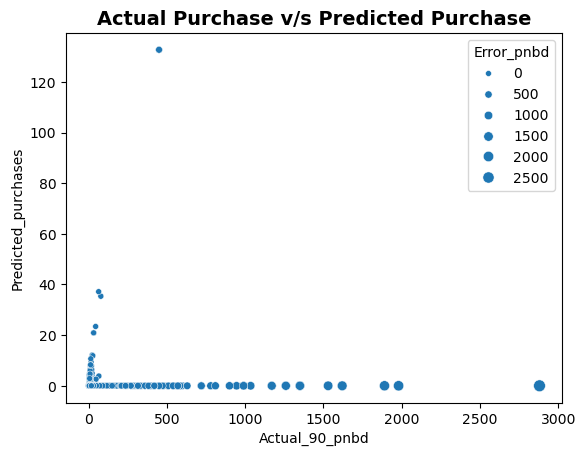

In [135]:
rfm_pareto = rfm_pareto.replace([np.inf, -np.inf], np.nan).fillna(0)
pnbd_mse_purchase = mean_squared_error(rfm_pareto['Actual_90_pnbd'], rfm_pareto['Predicted_purchases'])
pnbd_rmse_purchase = np.sqrt(pnbd_mse_purchase)
pnbd_avg_error_purchase = rfm_pareto['Error_pnbd'].mean()

# NOTE : This error is based on the 90 days window period, it may vary as you adjust the window period.
print(f"Mean Squared Error : {pnbd_mse_purchase:.4f}")
print(f"Root Mean Squared Error : {pnbd_rmse_purchase:.4f}")
print(f"Average Purchase Error : {pnbd_avg_error_purchase:.4f}")

# Visualization
sns.scatterplot(rfm_pareto, x= "Actual_90_pnbd", y= "Predicted_purchases", size = rfm_pareto["Error_pnbd"])
plt.title("Actual Purchase v/s Predicted Purchase", fontsize=14, fontweight='bold')
plt.show()


##### **4.1.2. Gamma Gamma Distribution Model**


In [136]:
rfm_pnbd = rfm_pareto[(rfm_pareto['Frequency']>0) & (rfm_pareto['Monetary'] > 0)]
display(rfm_pnbd.head())
display_md(f'**Customers with atleast 1 repeat purchase** : {len(df_summary)}')


,ID,Recency,Frequency,Monetary,T,p_alive,p_not_alive,Predicted_purchases,Actual_90_pnbd,Error_pnbd
0,5524,58,22,1617,663,0.0000,1.0000,0.0000,34.1379,34.1379
1,2174,38,4,27,113,0.0226,0.9774,0.0656,9.4737,9.4081
2,4141,26,20,776,312,0.0000,1.0000,0.0000,69.2308,69.2308
3,6182,26,6,53,139,0.0001,0.9999,0.0002,20.7692,20.7690
4,5324,94,14,422,161,0.0040,0.9960,0.0264,13.4043,13.3779


**Customers with atleast 1 repeat purchase** : 2061

In [138]:
## Compute Average Profit Per Transaction using Gamam-Gamma Approach

# model fits in average sales per transaction 
rfm_pnbd.loc[:,'Avg_Monetary_pnbd'] = rfm_pnbd['Monetary'] / rfm_pnbd['Frequency']
ggf_pareto = GammaGammaFitter(penalizer_coef = 0.01)
ggf_pareto.fit(rfm_pnbd['Frequency'], rfm_pnbd['Avg_Monetary_pnbd'])
display_md("**Gamma-Gamma Model Parameters :**")
display(ggf_pareto.summary)

rfm_pnbd['Predicted_Avg_Sales_pnbd'] = ggf_pareto.conditional_expected_average_profit(rfm_pnbd['Frequency'],rfm_pnbd['Avg_Monetary_pnbd'])
display_md('**RFM Dataset :**')
display(rfm_pnbd.head())


**Gamma-Gamma Model Parameters :**

,coef,se(coef),lower 95% bound,upper 95% bound
p,3.474162,0.098856,3.280403,3.667921
q,0.845742,0.022733,0.801186,0.890298
v,3.421026,0.100205,3.224625,3.617427


**RFM Dataset :**

,ID,Recency,Frequency,Monetary,T,p_alive,p_not_alive,Predicted_purchases,Actual_90_pnbd,Error_pnbd,Avg_Monetary_pnbd,Predicted_Avg_Sales_pnbd
0,5524,58,22,1617,663,0.0000,1.0000,0.0000,34.1379,34.1379,73.500000,73.804457
1,2174,38,4,27,113,0.0226,0.9774,0.0656,9.4737,9.4081,6.750000,7.690625
2,4141,26,20,776,312,0.0000,1.0000,0.0000,69.2308,69.2308,38.800000,39.057763
3,6182,26,6,53,139,0.0001,0.9999,0.0002,20.7692,20.7690,8.833333,9.473611
4,5324,94,14,422,161,0.0040,0.9960,0.0264,13.4043,13.3779,30.142857,30.483897


In [139]:
print(f"Predicted Average Sales: {rfm_pnbd["Predicted_Avg_Sales_pnbd"].mean():.4f}")
print(f"Actual Average Sales: {rfm_pnbd["Avg_Monetary_pnbd"].mean():.4f}")
print(f"Difference: {(rfm_pnbd["Avg_Monetary_pnbd"].mean() - rfm_pnbd["Predicted_Avg_Sales_pnbd"].mean()):.4f}")
print(f"Mean Squared Error: {(mean_squared_error(rfm_pnbd["Avg_Monetary_pnbd"], rfm_pnbd["Predicted_Avg_Sales_pnbd"])):.4f}")
print(f"Root Mean Squared Error: {(sqrt(mean_squared_error(rfm_pnbd["Avg_Monetary_pnbd"], rfm_pnbd["Predicted_Avg_Sales_pnbd"]))):.4f}")
      

Predicted Average Sales: 38.3707
Actual Average Sales: 37.8101
Difference: -0.5605
Mean Squared Error: 0.5408
Root Mean Squared Error: 0.7354


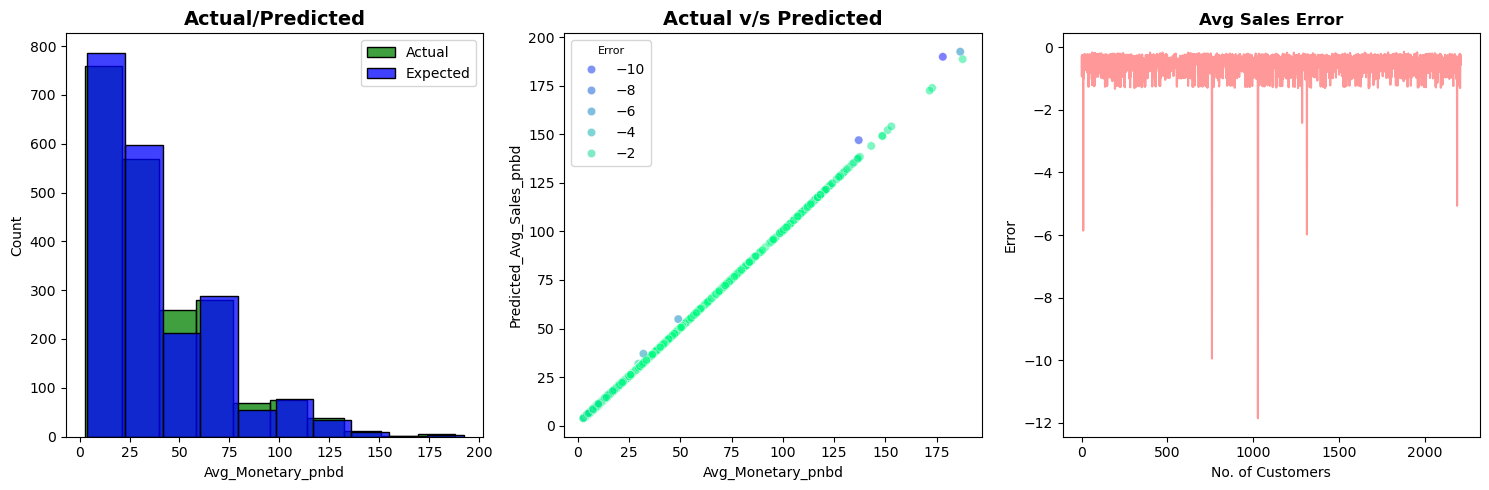

In [140]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(rfm_pnbd["Avg_Monetary_pnbd"], color = "g", bins=10, kde = False, ax = ax[0])
sns.histplot(rfm_pnbd["Predicted_Avg_Sales_pnbd"], color = "b", bins=10, kde = False, ax=ax[0])
ax[0].set_title("Actual/Predicted", fontsize=14, fontweight='bold')
ax[0].legend(["Actual", "Expected"])

error = (rfm_pnbd["Avg_Monetary_pnbd"]-rfm_pnbd["Predicted_Avg_Sales_pnbd"])

sns.scatterplot(data=rfm_pnbd, x="Avg_Monetary_pnbd", y="Predicted_Avg_Sales_pnbd", alpha = 0.5, hue = error, palette = "winter",ax=ax[1])
ax[1].set_title("Actual v/s Predicted", fontsize=14, fontweight='bold')
ax[1].legend(title='Error', title_fontsize=8)

ax[2].plot(error, color = 'r', alpha = 0.4)
ax[2].set_title("Avg Sales Error", fontsize=12, fontweight='bold')
ax[2].set_xlabel('No. of Customers')
ax[2].set_ylabel('Error')

plt.tight_layout()
plt.subplots_adjust(hspace=0.1)
plt.show()


In [142]:
## Compute CLTV using Gamma-Gamma Model + Pareto/NBD
# The customers' lifetime values expected to in the next 3 months
pnbd_model.fit(rfm_pnbd['Frequency'], rfm_pnbd['Recency'], rfm_pnbd['T'])
rfm_pnbd['Predicted_cltv_pnbd'] = ggf_pareto.customer_lifetime_value(
    pnbd_model,  # the model to use to predict the number of future transactions
    rfm_pnbd['Frequency'],rfm_pnbd['Recency'],rfm_pnbd['T'],rfm_pnbd['Avg_Monetary_pnbd'],
    time=3,  #3 months
    freq="M",  #frequency information of T. In this case we set week by using 'D'
    discount_rate=0.01).map(lambda x: f"{x:.2f}").astype(float)

# Actual CLTV
# Manual predict clv = Predicted no. of transactions * Expected avg sales * profit_margin to compute profit from each transaction
profit_margin = 0.05
rfm_pnbd['Manual_pnbd_cltv'] = (rfm_pnbd['Predicted_purchases'] * rfm_pnbd['Predicted_Avg_Sales_pnbd'] * profit_margin).map(lambda x: f"{x:.2f}").astype(float)

display(rfm_pnbd.head())


c:\Users\Admin\anaconda3\envs\test_titanic\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,ID,Recency,Frequency,Monetary,T,p_alive,p_not_alive,Predicted_purchases,Actual_90_pnbd,Error_pnbd,Avg_Monetary_pnbd,Predicted_Avg_Sales_pnbd,Predicted_cltv_pnbd,Manual_pnbd_cltv
0,5524,58,22,1617,663,0.0000,1.0000,0.0000,34.1379,34.1379,73.500000,73.804457,0.00,0.00
1,2174,38,4,27,113,0.0226,0.9774,0.0656,9.4737,9.4081,6.750000,7.690625,0.01,0.03
2,4141,26,20,776,312,0.0000,1.0000,0.0000,69.2308,69.2308,38.800000,39.057763,0.00,0.00
3,6182,26,6,53,139,0.0001,0.9999,0.0002,20.7692,20.7690,8.833333,9.473611,0.00,0.00
4,5324,94,14,422,161,0.0040,0.9960,0.0264,13.4043,13.3779,30.142857,30.483897,0.01,0.04


In [143]:
# actual spend in 3 months
actual =  rfm_pnbd['Avg_Monetary_pnbd'] * rfm_pnbd['Actual_90_pnbd']

# predicted spend in 3 months
predicted = rfm_pnbd['Predicted_purchases'] * rfm_pnbd['Predicted_Avg_Sales_pnbd']

# Error
error = actual - predicted

# create dataframe
result_pnbd = pd.DataFrame([actual, predicted, error], index = ["Actual", "Predicted", "Error"]).T
display(result_pnbd.head())

print(f"Average Error: {result_pnbd["Error"].mean()}")
print(f"Mean Squared Error: {mean_squared_error(result_pnbd["Actual"], result_pnbd["Predicted"])}")
print(f"Root Mean Squared Error: {sqrt(mean_squared_error(result_pnbd["Actual"], result_pnbd["Predicted"]))}")


,Actual,Predicted,Error
0,2509.135650,0.000000,2509.135650
1,63.947475,0.504505,63.442970
2,2686.155040,0.000000,2686.155040
3,183.461267,0.001895,183.459372
4,404.043900,0.804775,403.239125


Average Error: 3170.2501310832304
Mean Squared Error: 125495489.01531522
Root Mean Squared Error: 11202.476914295125


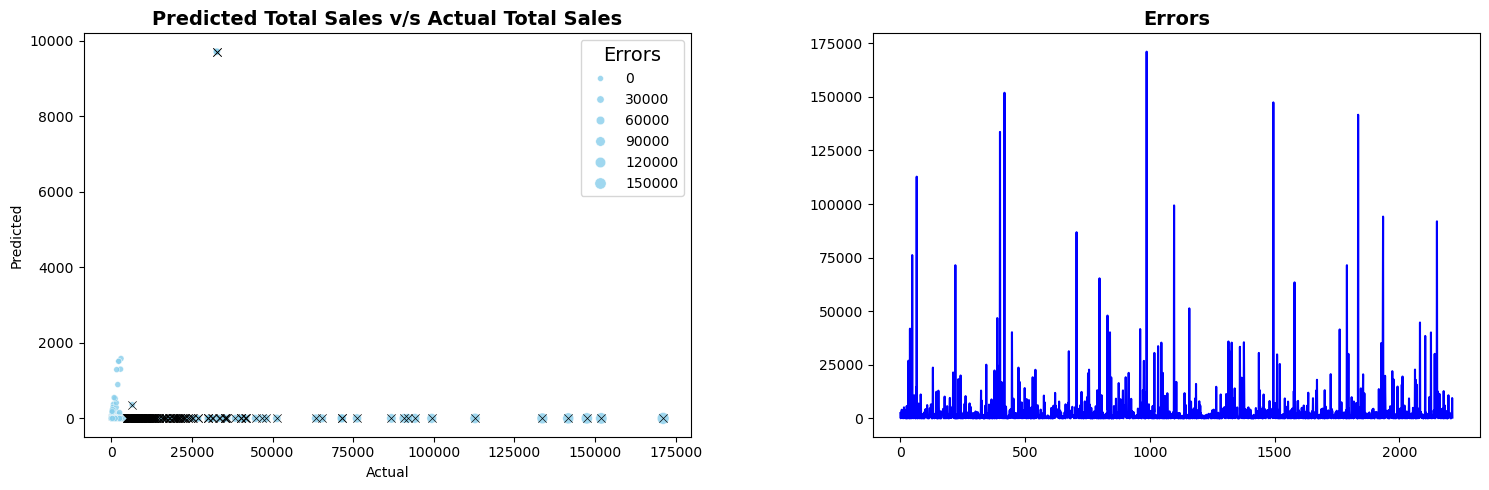

In [146]:
#Predicted v/s Actual
fig, ax = plt.subplots(1, 2, figsize=(15,5))

sns.scatterplot(data=result_pnbd, x="Actual", y="Predicted", size = "Error", color = "skyblue", alpha = 0.8, marker = 'o', ax=ax[0])
sns.scatterplot(x = result_pnbd[result_pnbd["Error"] > 5000]["Actual"], y=result_pnbd[result_pnbd["Error"] > 5000]["Predicted"], data=result, color = "k", marker = "x", ax=ax[0])
ax[0].set_title("Predicted Total Sales v/s Actual Total Sales", fontsize=14, fontweight='bold')
ax[0].legend(title='Errors', title_fontsize=14)

ax[1].plot(result["Error"], color = "b")
ax[1].set_title("Errors", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()


In [145]:
print(rfm_pnbd['Predicted_cltv_pnbd'].value_counts().nlargest(2))
print("\n"+"*"*20+ "*"*20, end="\n")
print(rfm_pnbd['Manual_pnbd_cltv'].value_counts().nlargest(2))


Predicted_cltv_pnbd
0.00    1857
0.01      40
Name: count, dtype: int64

****************************************
Manual_pnbd_cltv
0.00    1825
0.01      38
Name: count, dtype: int64


Since most of the CLV scores are zero, we categorize customers into two groups:

- **Profitable** (those with predicted CLTV greater than zero)
- **Non-Profitable** (those with predicted CLTV equal to zero).


#### **Reference Work :**

https://readmedium.com/measuring-customers-value-using-python-lifetimes-d8b19a04e9c1